<a href="https://colab.research.google.com/github/keswong/phd_listing_repo/blob/main/3_9_2_4_AudiBERT_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AudiBERT model adapted by Toto et al. (2021)
Toto, E., Tlachac, M., & Rundensteiner, E. A. (2021). AudiBERT: A Deep Transfer Learning Multimodal Classification Framework for Depression Screening. Proceedings of the 30th ACM International Conference on Information & Knowledge Management, 4145–4154. https://doi.org/10.1145/3459637.3481895.

Original Google Colab by Toto et al. (2021): https://colab.research.google.com/drive/1g_smMt_-qQZyq5EaXBEo8XBu2KrvhDLI?usp=sharing

Webpage by Toto et al. (2021): https://emutivo.wpi.edu/index.php/publications/


# AudiBERT classification report and normalised confusion matrix

Figure 5.1: Row-normalised confusion matrix with values in each cell showing the proportion of instances from the true class that were predicted as a particular class in the social-cognitive dimension for the implemented models.

Classification Report:
               precision    recall  f1-score   support

         SS1      0.263     0.233     0.247        43
         SS2      0.584     0.669     0.624       245
         SS3      0.316     0.343     0.329        70
         SS4      1.000     0.167     0.286         6
         SS5      0.533     0.421     0.471        19
         SS6      0.167     0.080     0.108        25
         SS7      0.000     0.000     0.000         4
         SS8      0.000     0.000     0.000        10
         SC1      0.689     0.752     0.719       318
         SC2      0.693     0.564     0.622       172

   micro avg      0.598     0.598     0.598       912
   macro avg      0.424     0.323     0.340       912
weighted avg      0.587     0.598     0.587       912
 samples avg      0.598     0.598     0.598       912

Accuracy: 0.598
Precision: 0.587
Recall: 0.598
F1 Score: 0.587



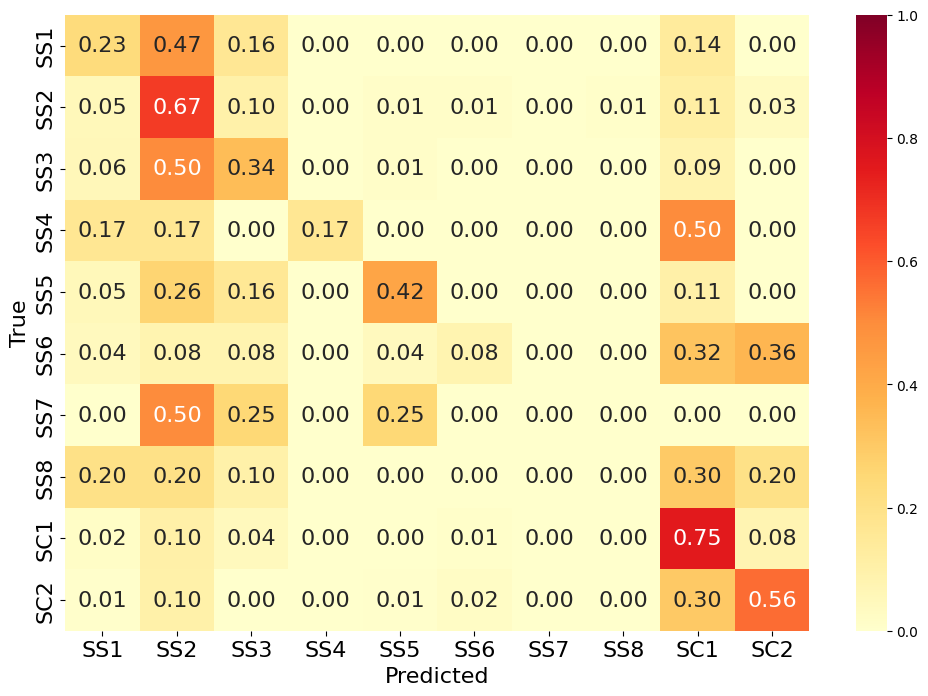

In [17]:
%reset -f
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load the data
data = pd.read_pickle('.../socialcognitive_testing_result_1.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==1]

# Label dictionary
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 16}
)

ax.set_xlabel('Predicted', fontsize=16)
ax.set_ylabel('True', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
plt.show()

# AudiBERT classification report and normalised confusion matrix

Figure 5.2: Row-normalised confusion matrix with values in each cell showing the proportion of instances from the true class that were predicted as a particular class in the affective dimension for the implemented models.

Classification Report:
               precision    recall  f1-score   support

         AS1      0.849     0.886     0.867       114
         AS2      0.922     0.897     0.909       184
         AS3      0.750     0.750     0.750         8

   micro avg      0.889     0.889     0.889       306
   macro avg      0.840     0.844     0.842       306
weighted avg      0.890     0.889     0.889       306
 samples avg      0.889     0.889     0.889       306

Accuracy: 0.889
Precision: 0.890
Recall: 0.889
F1 Score: 0.889



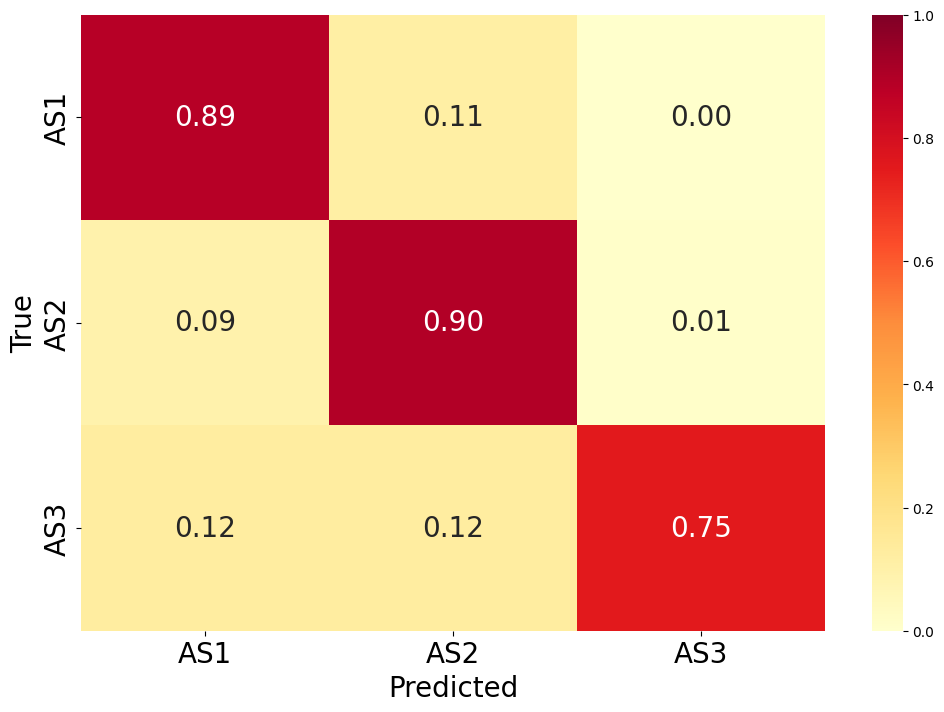

In [18]:
%reset -f
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load the data
data = pd.read_pickle('.../affective_testing_result_3.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==3]

# Label dictionary
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 20}
)

ax.set_xlabel('Predicted', fontsize=20)
ax.set_ylabel('True', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
plt.show()